# Load object with Nicheformer embeddings

In [1]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import scipy.sparse as sp

# =========================
# Inputs
# =========================
h5ad_path = "/oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/MATMA3_with_NFembeddings.h5ad"

embedding_key = "X_niche_NFembeddings"

# Optional metadata columns to color by
color_cols = [
    "HECoreID",
    "fov",
    "slide_ID",
    "niche",
    "Panel",
    "nCount_RNA",
    "nFeature_RNA",
]

# =========================
# Load object
# =========================
adata = ad.read_h5ad(h5ad_path)

print(adata)
print("\nobsm keys:", list(adata.obsm.keys()))

assert embedding_key in adata.obsm, f"{embedding_key} not found in adata.obsm"

X_nf = adata.obsm[embedding_key]

print("\nEmbedding shape:", X_nf.shape)
print("Embedding dtype:", X_nf.dtype)
print("NaNs:", np.isnan(X_nf).sum())
print("Min:", np.nanmin(X_nf))
print("Max:", np.nanmax(X_nf))
print("Mean:", np.nanmean(X_nf))
print("Std:", np.nanstd(X_nf))

AnnData object with n_obs × n_vars = 219363 × 20310
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_0.85', 'falsecode_quanti

In [2]:
emb_df = pd.DataFrame(
    adata.obsm[embedding_key][:10, :20],
    index=adata.obs_names[:10],
    columns=[f"NF_{i}" for i in range(20)]
)

emb_df

,NF_0,NF_1,NF_2,NF_3,NF_4,NF_5,NF_6,NF_7,NF_8,NF_9,NF_10,NF_11,NF_12,NF_13,NF_14,NF_15,NF_16,NF_17,NF_18,NF_19
1_1,-0.403727,0.457076,0.137933,0.394655,0.537089,0.224418,-0.309855,-0.026595,-0.006096,-0.410307,-0.024037,0.204362,0.237471,0.034745,-0.005389,-0.682474,0.201651,-0.058207,0.308026,0.067536
2_1,-0.582235,0.413125,0.147794,0.414327,0.295450,0.278647,-0.541732,-0.005236,0.062063,-0.596744,-0.322698,0.206112,0.165839,0.019126,0.225935,-0.923479,0.221818,0.159847,0.494721,0.025461
3_1,-0.409413,0.257017,0.174628,0.451425,0.257326,0.194732,-0.445170,-0.066656,0.094024,-0.481678,-0.237420,0.307260,0.170284,0.029581,0.123905,-0.826515,0.283744,-0.029624,0.345630,0.138852
4_1,-0.077360,0.028917,-0.087177,0.439476,0.486438,0.095750,-0.222414,0.135639,0.058194,-0.496765,-0.132200,0.256200,0.255784,-0.021247,0.130614,-0.711369,0.134500,0.017242,0.150212,-0.000686
5_1,-0.567945,0.383451,0.096090,0.432711,0.254266,0.308026,-0.374708,-0.013370,0.079622,-0.436388,-0.312168,0.142413,0.139838,0.006968,0.097853,-1.029721,0.220728,0.184977,0.527632,0.032035
6_1,-0.591012,0.340277,0.113635,0.429407,0.227805,0.201742,-0.358061,0.047174,0.131761,-0.389376,-0.178051,0.421432,0.122388,-0.043671,-0.033708,-0.934392,0.152757,0.085417,0.619639,0.146218
7_1,-0.453004,0.582112,0.243570,0.391117,0.224454,0.301722,-0.591700,-0.144041,-0.045822,-0.405511,-0.124141,0.146572,0.282622,0.057628,0.134167,-0.788671,0.283202,-0.049878,0.432237,0.122792
8_1,-0.613258,0.325337,0.028762,0.336747,0.203129,0.237594,-0.342313,0.028360,0.051129,-0.394600,-0.132101,0.440230,0.124405,0.037507,0.028085,-0.857104,0.135115,0.137699,0.553365,0.174195
9_1,-0.557304,0.386024,0.166482,0.452146,0.272345,0.200751,-0.355808,-0.020427,0.139480,-0.430621,-0.214696,0.384536,0.148178,-0.021194,0.115155,-0.967912,0.197697,0.003984,0.499856,0.051623
10_1,-0.080814,0.140192,0.158032,0.233855,0.337340,-0.037181,-0.089873,0.202455,-0.014053,-0.467915,-0.037661,0.300021,0.198337,-0.173292,-0.052039,-0.458156,0.143663,0.048486,0.116567,-0.140584


In [3]:
# Tell Scanpy to use Nicheformer embeddings as the representation
sc.pp.neighbors(
    adata,
    use_rep=embedding_key,
    n_neighbors=15,
    metric="cosine"
)

sc.tl.umap(adata)

# Save under a clear key
adata.obsm["X_umap_NF"] = adata.obsm["X_umap"].copy()

print(adata.obsm["X_umap_NF"].shape)

/home/groups/ccurtis2/bgsimon/miniconda/envs/nicheformer_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(219363, 2)


# Plot UMAPs

Available color columns: ['HECoreID', 'fov', 'slide_ID', 'Panel', 'nCount_RNA', 'nFeature_RNA']


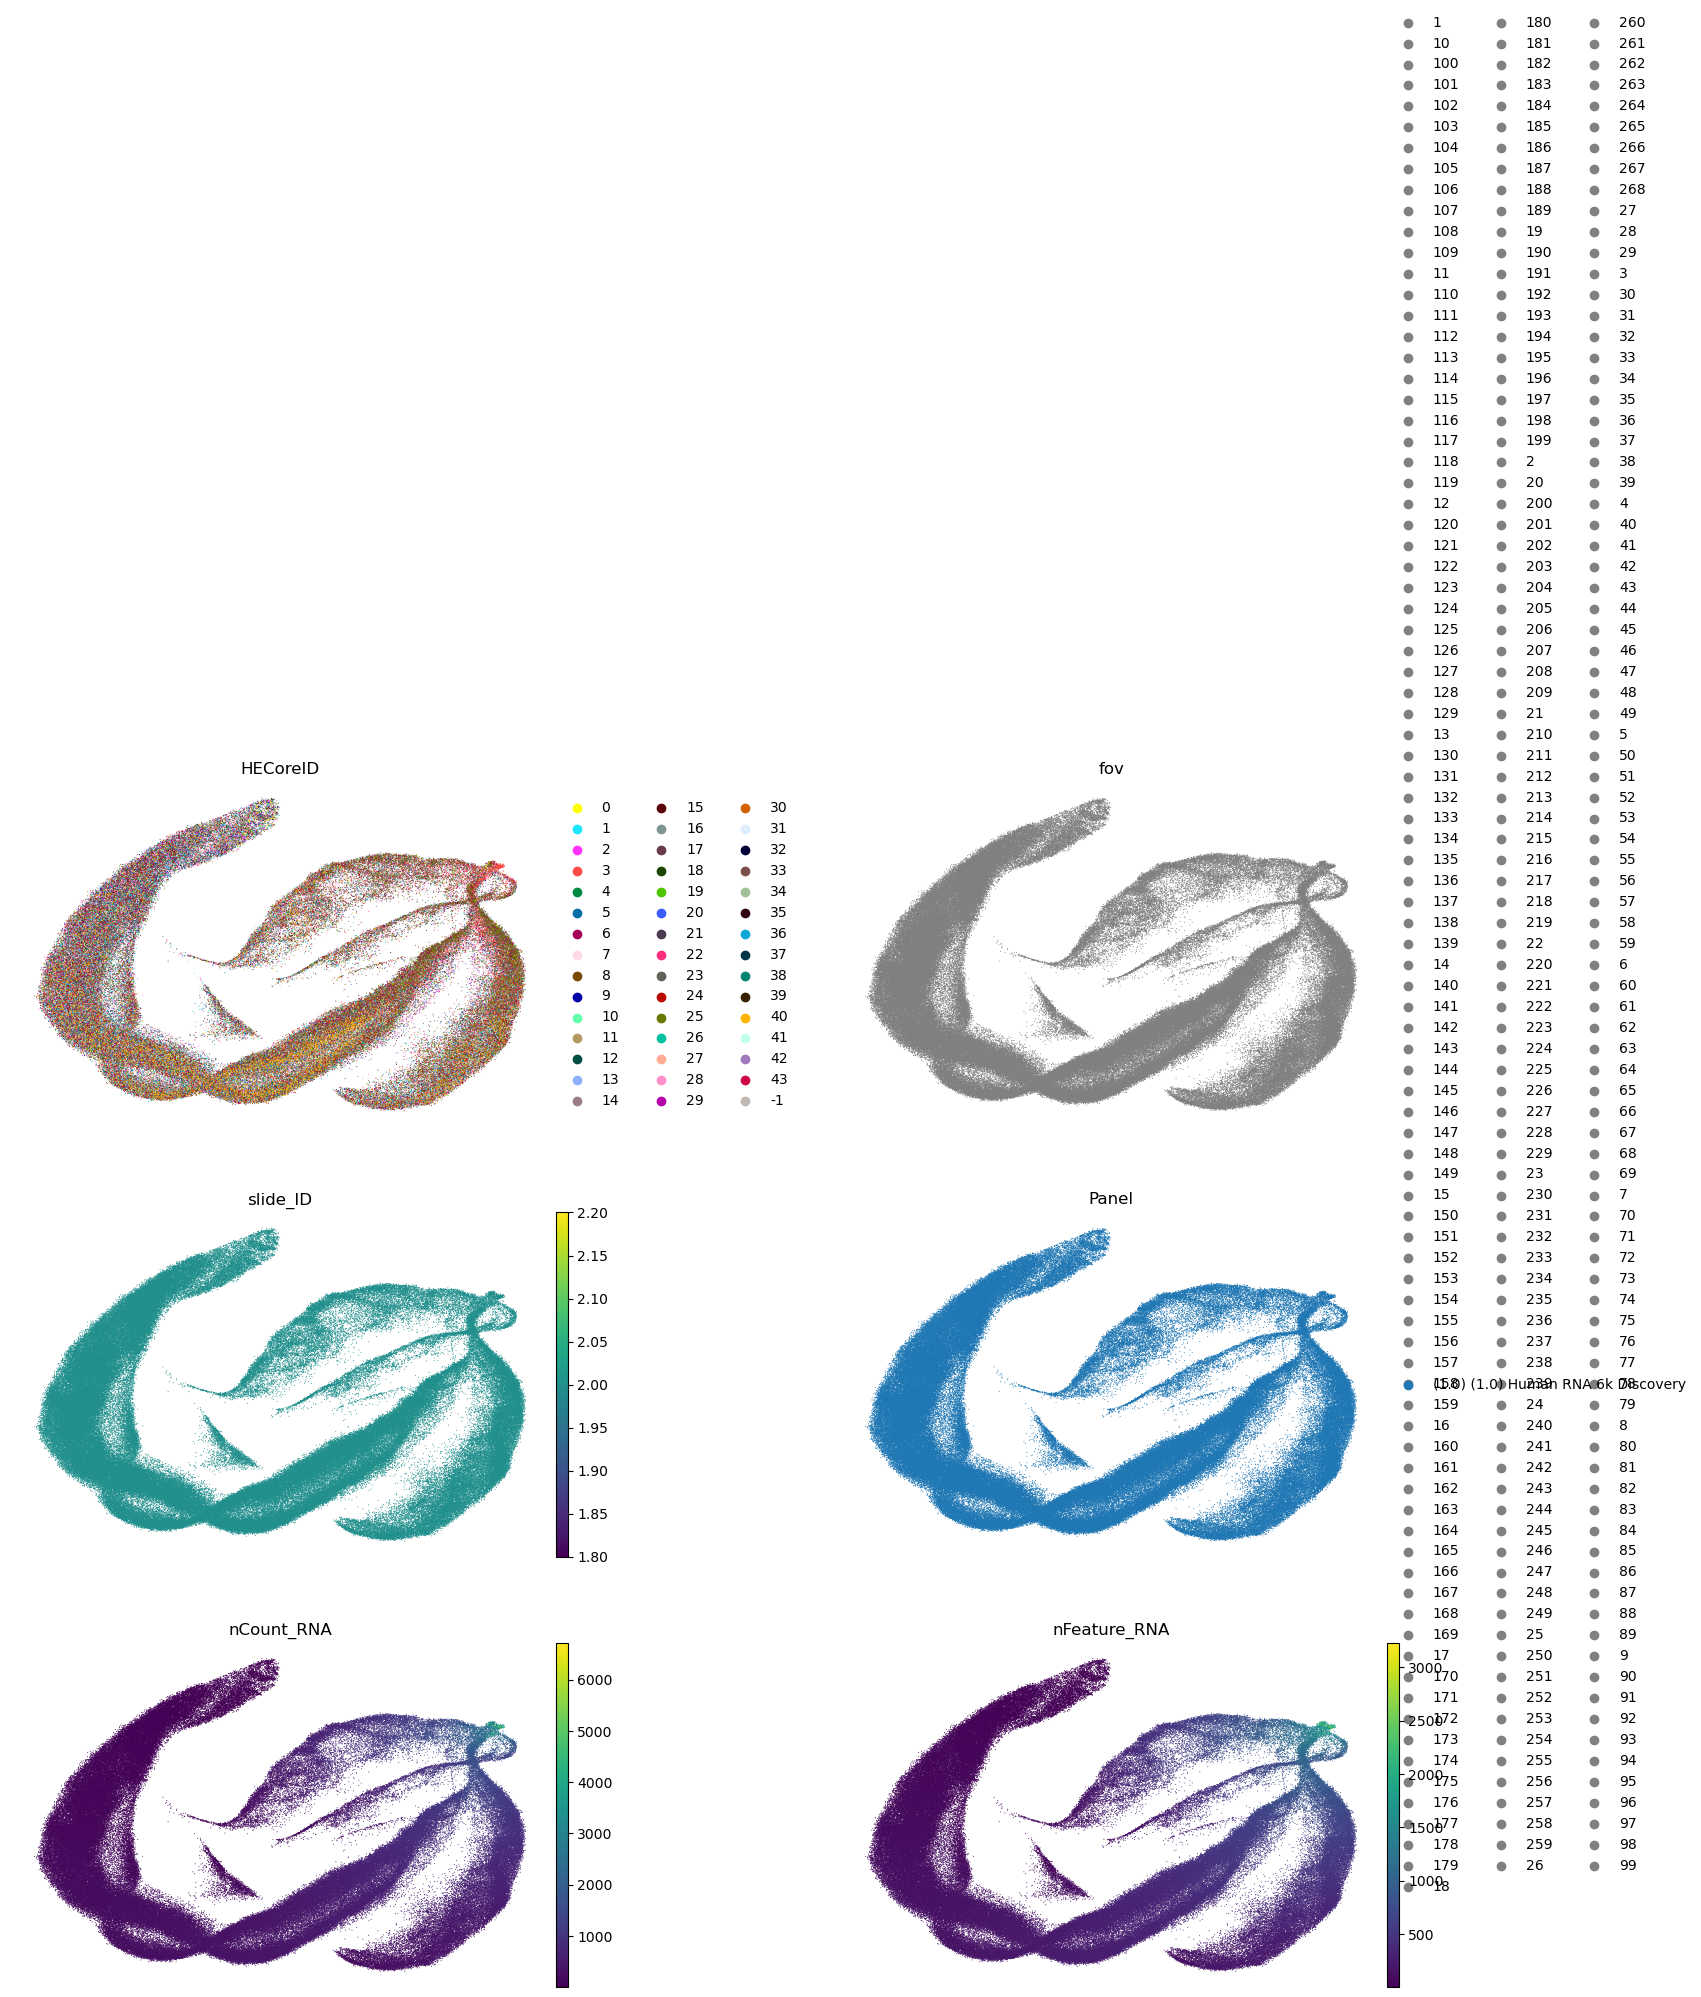

In [4]:
available_color_cols = [c for c in color_cols if c in adata.obs.columns]
print("Available color columns:", available_color_cols)

sc.pl.umap(
    adata,
    color=available_color_cols,
    size=2,
    ncols=2,
    wspace=0.4,
    frameon=False
)

# Plot expression of multiple genes

In [3]:
import mygene
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scanpy as sc

genes_to_plot = [
    "EPCAM",
    "KRT8",
    "KRT18",
    "PTPRC",
    "CD68",
    "COL1A1",
    "VIM",
]

mg = mygene.MyGeneInfo()

query = mg.querymany(
    genes_to_plot,
    scopes="symbol",
    fields="ensembl.gene,symbol",
    species="human",
    as_dataframe=True,
    df_index=True,
    verbose=False,
)

symbol_to_ens = {}

for symbol in genes_to_plot:
    if symbol not in query.index:
        print(f"No query result for {symbol}")
        continue

    row = query.loc[symbol]

    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]

    ens = row.get("ensembl.gene", None)

    if isinstance(ens, list):
        ens = ens[0]

    if pd.notna(ens):
        ens = str(ens).split(".")[0]
        symbol_to_ens[symbol] = ens

print(symbol_to_ens)

{'EPCAM': 'ENSG00000119888', 'KRT8': 'ENSG00000170421', 'KRT18': 'ENSG00000111057', 'CD68': 'ENSG00000129226', 'COL1A1': 'ENSG00000108821', 'VIM': 'ENSG00000026025'}


In [4]:
def add_gene_expression_to_obs(adata, symbol_to_ens):
    for symbol, ens in symbol_to_ens.items():
        if ens not in adata.var_names:
            print(f"Skipping {symbol}: {ens} not in adata.var_names")
            continue

        idx = adata.var_names.get_loc(ens)
        col = adata.X[:, idx]

        if sp.issparse(col):
            vals = col.toarray().ravel()
        else:
            vals = np.asarray(col).ravel()

        adata.obs[f"{symbol}_expr"] = vals
        print(f"Added {symbol}_expr from {ens}")

add_gene_expression_to_obs(adata, symbol_to_ens)

gene_expr_cols = [f"{g}_expr" for g in genes_to_plot if f"{g}_expr" in adata.obs.columns]
print(gene_expr_cols)

Added EPCAM_expr from ENSG00000119888
Added KRT8_expr from ENSG00000170421
Added KRT18_expr from ENSG00000111057
Added CD68_expr from ENSG00000129226
Added COL1A1_expr from ENSG00000108821
Added VIM_expr from ENSG00000026025
['EPCAM_expr', 'KRT8_expr', 'KRT18_expr', 'CD68_expr', 'COL1A1_expr', 'VIM_expr']


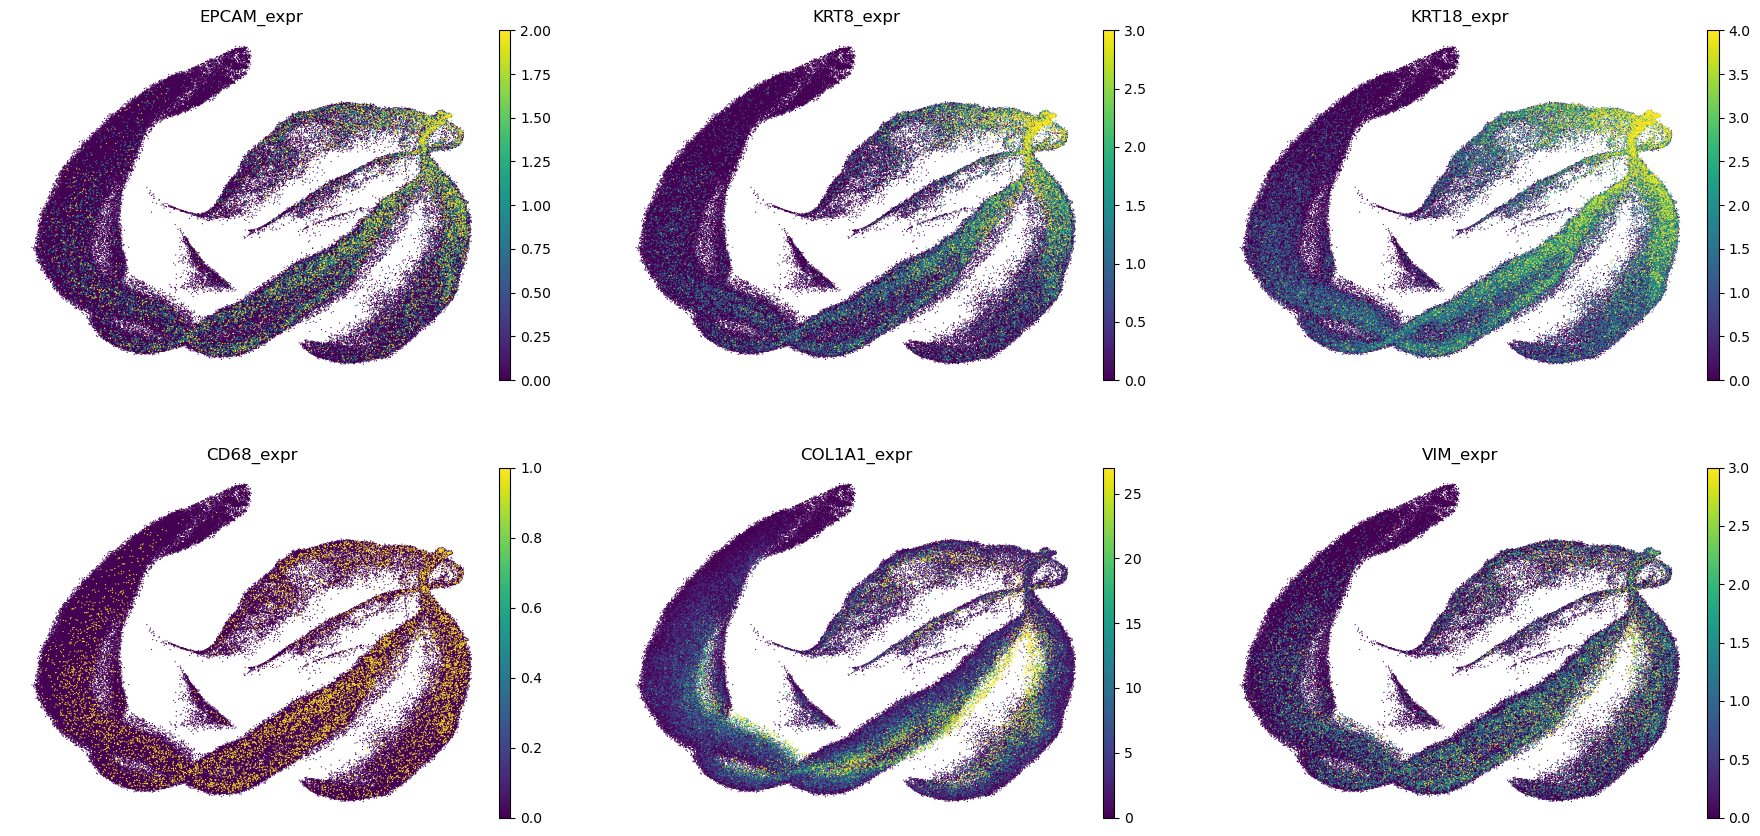

In [7]:
adata.obsm["X_nf_umap_plot"] = adata.obsm["X_umap_NF"]

sc.pl.embedding(
    adata,
    basis="nf_umap_plot",
    color=gene_expr_cols,
    size=3,
    cmap="viridis",
    ncols=3,
    vmin="p1",
    vmax="p99",
    frameon=False
)

# Directly plot expression of a single gene

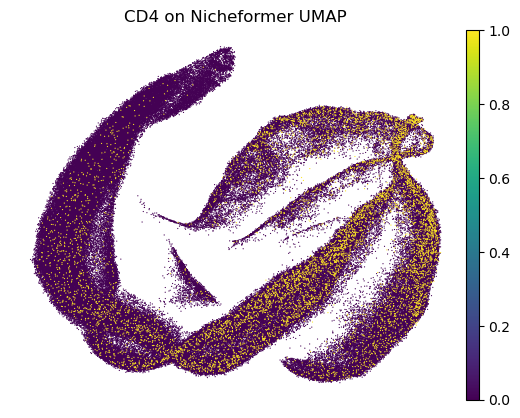

In [8]:
import mygene
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scanpy as sc

gene = "CD4"

mg = mygene.MyGeneInfo()
query = mg.querymany(
    [gene],
    scopes="symbol",
    fields="ensembl.gene,symbol",
    species="human",
    as_dataframe=True,
    df_index=True,
    verbose=False,
)

row = query.loc[gene]
if isinstance(row, pd.DataFrame):
    row = row.iloc[0]

ens = row.get("ensembl.gene", None)
if isinstance(ens, list):
    ens = ens[0]
ens = str(ens).split(".")[0]

idx = adata.var_names.get_loc(ens)
col = adata.X[:, idx]

if sp.issparse(col):
    vals = col.toarray().ravel()
else:
    vals = np.asarray(col).ravel()

adata.obs[f"{gene}_expr"] = vals

adata.obsm["X_nf_umap_plot"] = adata.obsm["X_umap_NF"]

sc.pl.embedding(
    adata,
    basis="nf_umap_plot",
    color=f"{gene}_expr",
    size=3,
    cmap="viridis",
    vmin=0,
    vmax="p99",
    frameon=False,
    title=f"{gene} on Nicheformer UMAP"
)

# Leiden clustering

In [12]:
# =========================
# Parameters
# =========================
embedding_key = "X_niche_NFembeddings"
cluster_key = "leiden_NF"
resolution = 1.0

# =========================
# Build neighbor graph from Nicheformer embeddings
# =========================
sc.pp.neighbors(
    adata,
    use_rep=embedding_key,
    n_neighbors=15,
    metric="cosine",
    key_added="neighbors_NF"
)

# =========================
# Leiden clustering
# =========================
sc.tl.leiden(
    adata,
    resolution=resolution,
    key_added=cluster_key,
    neighbors_key="neighbors_NF"
)

print(adata.obs[cluster_key].value_counts().sort_index())

/home/groups/ccurtis2/bgsimon/miniconda/envs/nicheformer_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_5608/1639462953.py:22: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


0     20733
1     19698
2     18993
3     17196
4     17144
5     13940
6     13896
7     12791
8     12630
9     12587
10    11731
11     9980
12     8690
13     8491
14     6625
15     5472
16     4800
17     3578
18      388
Name: leiden_NF, dtype: int64


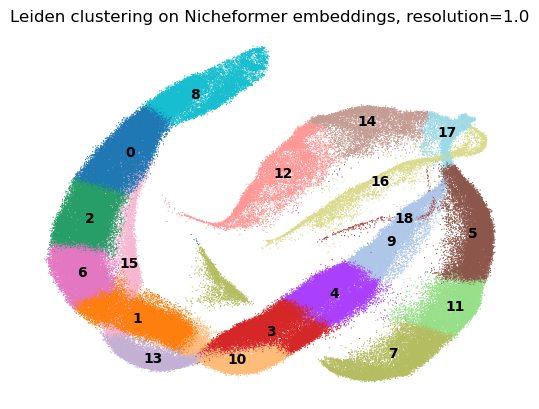

In [13]:
# Make Scanpy-friendly alias
adata.obsm["X_nf_umap_plot"] = adata.obsm["X_umap_NF"]

sc.pl.embedding(
    adata,
    basis="nf_umap_plot",
    color=cluster_key,
    size=3,
    legend_loc="on data",
    frameon=False,
    title=f"Leiden clustering on Nicheformer embeddings, resolution={resolution}"
)

# Test multiple Leiden resolutions

In [16]:
resolutions = [0.1, 0.2, 0.5, 1.0, 2.0]

for res in resolutions:
    key = f"leiden_NF_res{res}"
    
    sc.tl.leiden(
        adata,
        resolution=res,
        key_added=key,
        neighbors_key="neighbors_NF"
    )
    
    print("\n", key)
    print(adata.obs[key].value_counts().sort_index())


 leiden_NF_res0.1
0    63323
1    54230
2    41483
3    39984
4    15246
5     4750
6      347
Name: leiden_NF_res0.1, dtype: int64


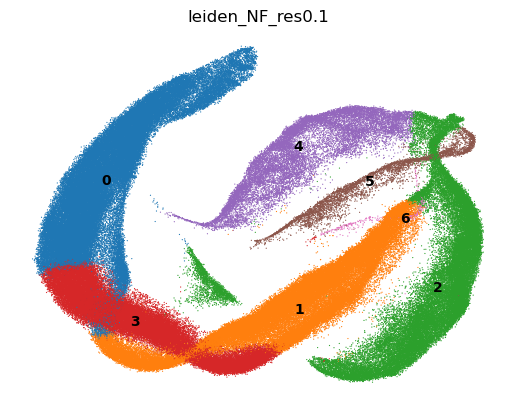

In [17]:
keys_to_plot = [f"leiden_NF_res{res}" for res in resolutions]

sc.pl.embedding(
    adata,
    basis="nf_umap_plot",
    color=keys_to_plot,
    size=3,
    legend_loc="on data",
    frameon=False,
    ncols=2
)

# DEG analysis

In [6]:
# =========================
# Filter cells with >100 total transcripts
# =========================

# Prefer existing CosMx count column if available
if "nCount_RNA" in adata.obs.columns:
    total_transcripts = adata.obs["nCount_RNA"].astype(float).values
else:
    total_transcripts = np.asarray(adata.X.sum(axis=1)).ravel()

mask = total_transcripts > 100

print("Original cells:", adata.n_obs)
print("Cells with >100 transcripts:", mask.sum())
print("Filtered out:", (~mask).sum())

adata_filt = adata[mask].copy()

Original cells: 219363
Cells with >100 transcripts: 175782
Filtered out: 43581


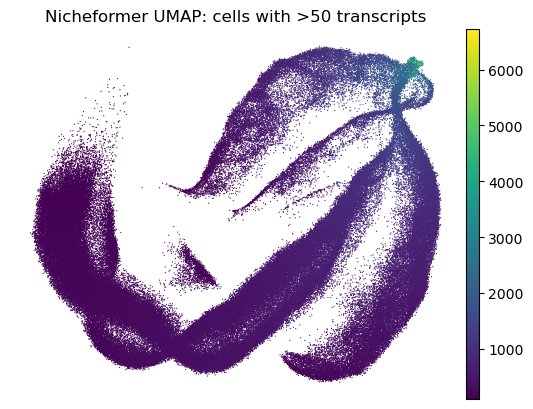

In [7]:
# =========================
# Plot existing Nicheformer UMAP after filtering
# =========================

# Use saved Nicheformer UMAP
adata_filt.obsm["X_nf_umap_plot"] = adata_filt.obsm["X_umap_NF"]

sc.pl.embedding(
    adata_filt,
    basis="nf_umap_plot",
    color=["nCount_RNA"] if "nCount_RNA" in adata_filt.obs.columns else None,
    size=3,
    cmap="viridis",
    frameon=False,
    title="Nicheformer UMAP: cells with >50 transcripts"
)

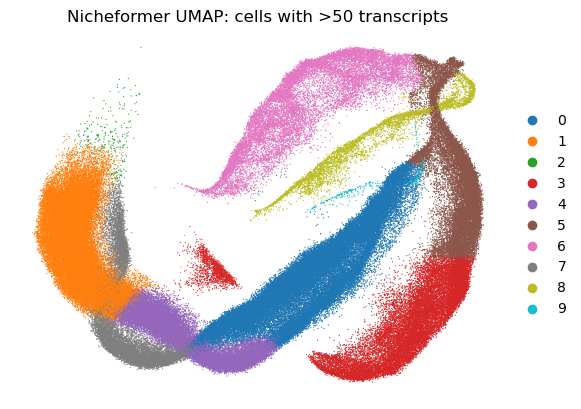

In [9]:
cluster_key = "leiden_NF_res0.2"

sc.pl.embedding(
    adata_filt,
    basis="nf_umap_plot",
    color=cluster_key if cluster_key in adata_filt.obs.columns else None,
    size=3,
    frameon=False,
    title="Nicheformer UMAP: cells with >50 transcripts"
)

/home/groups/ccurtis2/bgsimon/miniconda/envs/nicheformer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/__init__.py:449: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ymin, ymax)


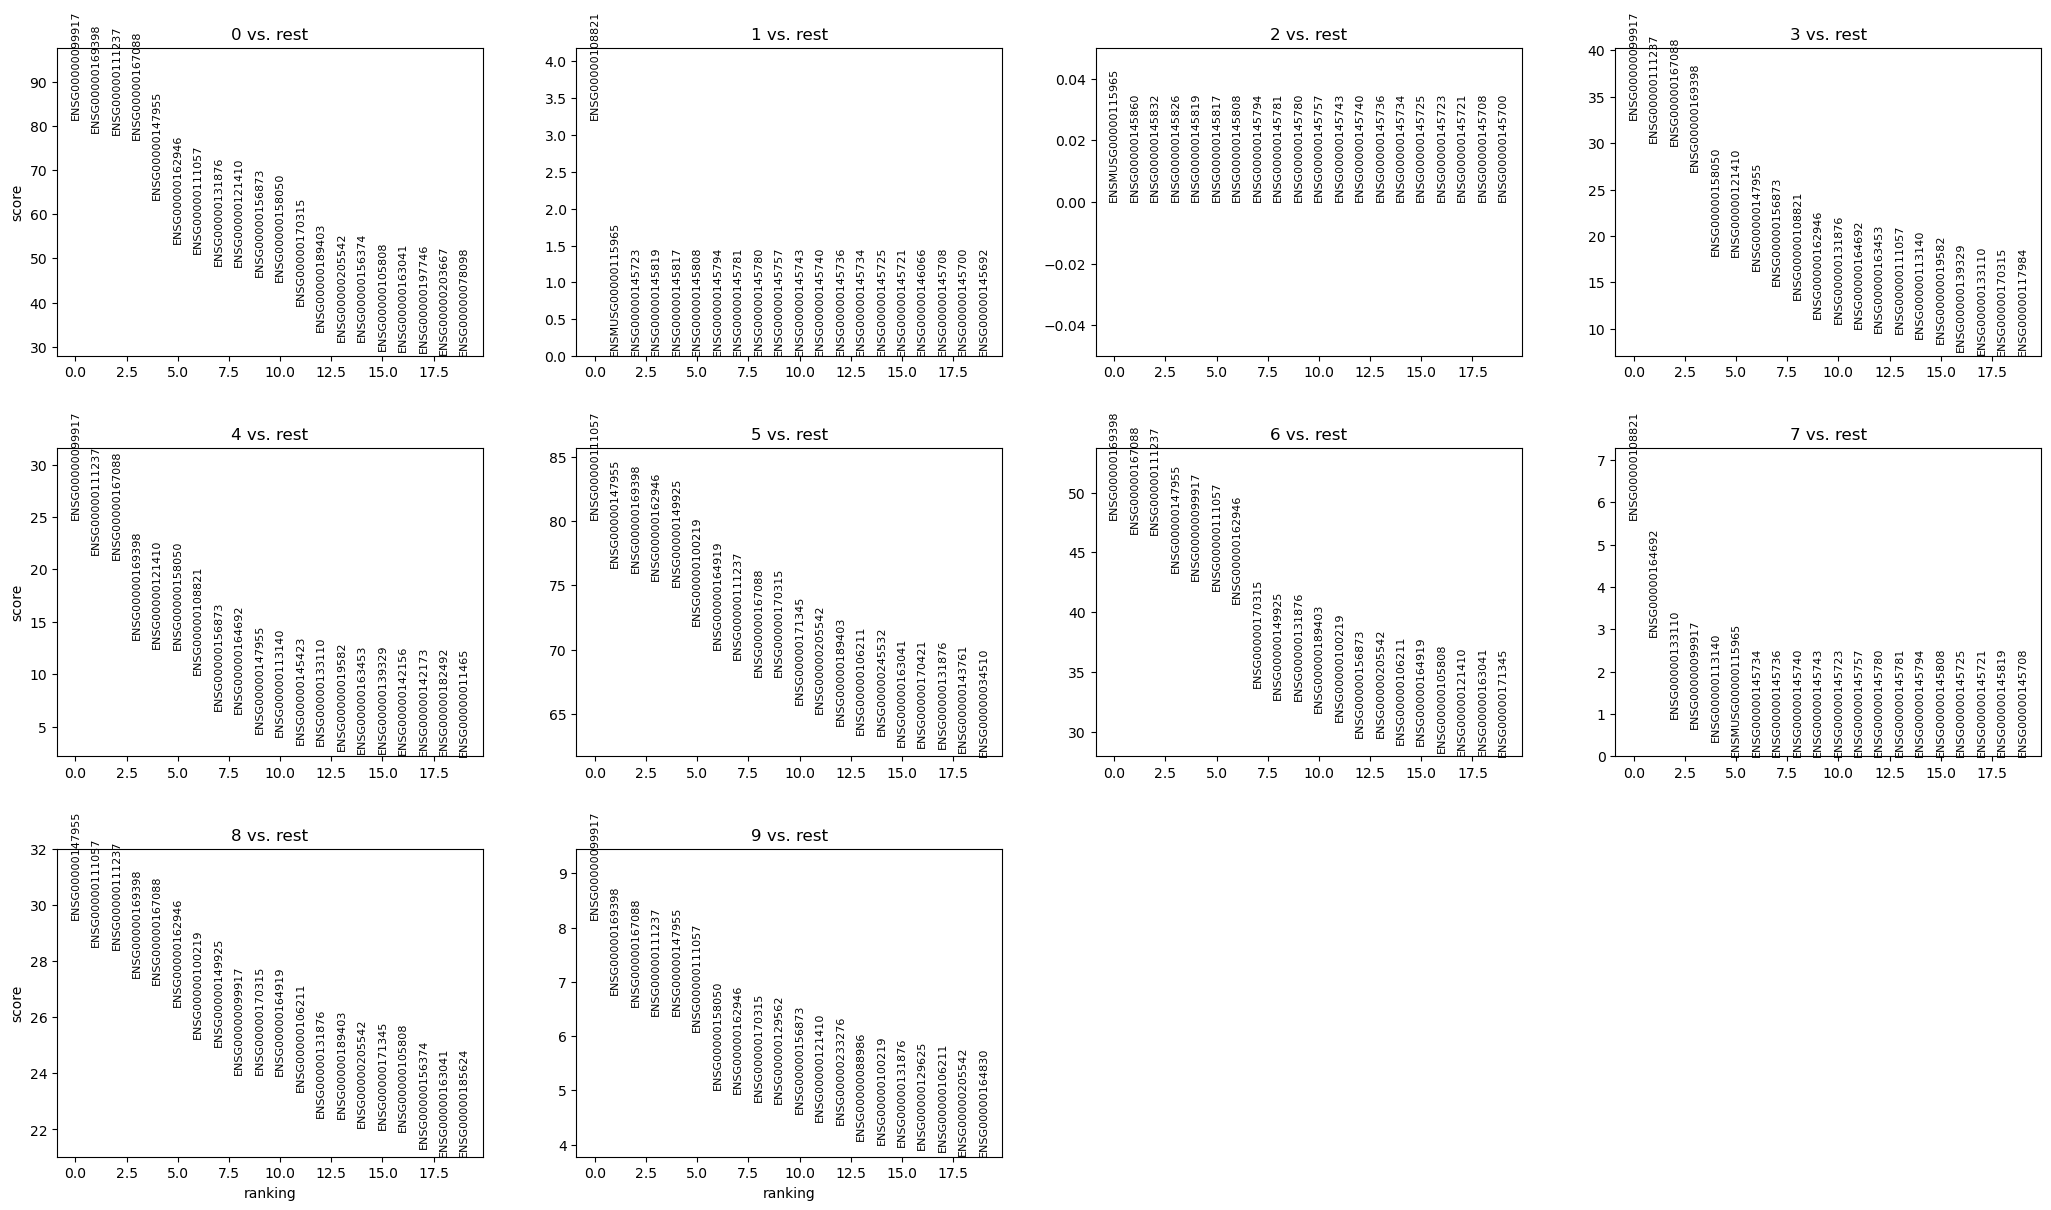

In [11]:
# =========================
# Prepare object for DE
# =========================
adata_de = adata.copy()

# Save Ensembl IDs
adata_de.var["ensembl_id"] = adata_de.var_names.astype(str)

# Normalize/log transform for DE
sc.pp.normalize_total(adata_de, target_sum=1e4)
sc.pp.log1p(adata_de)

# =========================
# Rank DEGs per Leiden cluster
# =========================
sc.tl.rank_genes_groups(
    adata_de,
    groupby=cluster_key,
    method="wilcoxon",
    key_added=deg_key,
    use_raw=False,
    pts=True
)

sc.pl.rank_genes_groups(
    adata_de,
    key=deg_key,
    n_genes=20,
    sharey=False
)

In [12]:
# =========================
# Export all DEGs per cluster
# =========================
all_deg_tables = []

clusters = adata_de.obs[cluster_key].astype("category").cat.categories

for cluster in clusters:
    df = sc.get.rank_genes_groups_df(
        adata_de,
        group=cluster,
        key=deg_key
    )

    df["cluster"] = cluster
    df = df.rename(columns={"names": "ensembl_id"})

    all_deg_tables.append(df)

all_degs = pd.concat(all_deg_tables, axis=0)

all_degs.to_csv(
    f"{out_dir}/all_clusters_DEGs_ensembl.csv",
    index=False
)

print("Saved:", f"{out_dir}/all_clusters_DEGs_ensembl.csv")
print(all_degs.head())

Saved: /oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/DEG_leiden_NF_res0.2/all_clusters_DEGs_ensembl.csv
        ensembl_id     scores  logfoldchanges  pvals  pvals_adj  pct_nz_group  \
0  ENSG00000099917  81.557518        1.927182    0.0        0.0      0.884669   
1  ENSG00000169398  78.568451        1.704458    0.0        0.0      0.755594   
2  ENSG00000111237  78.052727        1.896065    0.0        0.0      0.902718   
3  ENSG00000167088  76.810982        1.753674    0.0        0.0      0.967442   
4  ENSG00000147955  63.223949        1.344179    0.0        0.0      0.506184   

   pct_nz_reference cluster  
0          0.557520       0  
1          0.453027       0  
2          0.587803       0  
3          0.747844       0  
4          0.298291       0  


In [13]:
# =========================
# Add gene symbols with mygene
# =========================
unique_ens = all_degs["ensembl_id"].dropna().astype(str).unique().tolist()

mg = mygene.MyGeneInfo()

query = mg.querymany(
    unique_ens,
    scopes="ensembl.gene",
    fields="symbol,name",
    species="human",
    as_dataframe=True,
    df_index=True,
    verbose=False,
)

ens_to_symbol = {}
ens_to_name = {}

for ens in unique_ens:
    if ens not in query.index:
        continue

    row = query.loc[ens]

    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]

    symbol = row.get("symbol", None)
    name = row.get("name", None)

    if pd.notna(symbol):
        ens_to_symbol[ens] = symbol

    if pd.notna(name):
        ens_to_name[ens] = name

all_degs["gene_symbol"] = all_degs["ensembl_id"].map(ens_to_symbol)
all_degs["gene_name"] = all_degs["ensembl_id"].map(ens_to_name)

# Reorder columns
preferred_cols = [
    "cluster",
    "gene_symbol",
    "gene_name",
    "ensembl_id",
    "scores",
    "logfoldchanges",
    "pvals",
    "pvals_adj",
    "pct_nz_group",
    "pct_nz_reference",
]

existing = [c for c in preferred_cols if c in all_degs.columns]
remaining = [c for c in all_degs.columns if c not in existing]

all_degs = all_degs[existing + remaining]

out_csv = f"{out_dir}/all_clusters_DEGs_with_symbols.csv"
all_degs.to_csv(out_csv, index=False)

print("Saved:", out_csv)
all_degs.head(50)

Saved: /oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/DEG_leiden_NF_res0.2/all_clusters_DEGs_with_symbols.csv


,cluster,gene_symbol,gene_name,ensembl_id,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,MED15,mediator complex subunit 15,ENSG00000099917,81.557518,1.927182,0.000000e+00,0.000000e+00,0.884669,0.557520
1,0,PTK2,protein tyrosine kinase 2,ENSG00000169398,78.568451,1.704458,0.000000e+00,0.000000e+00,0.755594,0.453027
2,0,VPS29,VPS29 retromer complex component,ENSG00000111237,78.052727,1.896065,0.000000e+00,0.000000e+00,0.902718,0.587803
3,0,SNRPD1,small nuclear ribonucleoprotein D1 polypeptide,ENSG00000167088,76.810982,1.753674,0.000000e+00,0.000000e+00,0.967442,0.747844
4,0,SIGMAR1,sigma non-opioid intracellular receptor 1,ENSG00000147955,63.223949,1.344179,0.000000e+00,0.000000e+00,0.506184,0.298291
5,0,DISC1,DISC1 scaffold protein,ENSG00000162946,53.294662,1.169081,0.000000e+00,0.000000e+00,0.426034,0.254322
6,0,KRT18,keratin 18,ENSG00000111057,51.202278,1.138977,0.000000e+00,0.000000e+00,0.416528,0.251966
7,0,SNRPA1,small nuclear ribonucleoprotein polypeptide A',ENSG00000131876,48.375061,1.047243,0.000000e+00,0.000000e+00,0.448956,0.282150
8,0,A1BG,alpha-1-B glycoprotein,ENSG00000121410,48.267330,1.220290,0.000000e+00,0.000000e+00,0.772026,0.534940
9,0,PHKG2,phosphorylase kinase catalytic subunit gamma 2,ENSG00000156873,45.996994,0.999857,0.000000e+00,0.000000e+00,0.476160,0.306857


# Niche analysis


Transfer summary:
Total cells: 219363
Cell type labeled: 171842
Cell type missing: 47521
Niche labeled: 169664
Niche missing: 49699

Top SingleR_ind counts:


Fibroblasts                      47559
NoLabel                          47521
Cancer Epithelial Cells          42529
Epithelial Cells                 17154
Plasma Cells                     10040
Macrophages_SPP1-                 9879
Endothelial Cells                 6327
B Cells                           4910
Myoepithelial Cells               4194
Perivascular-like (PVL) Cells     3915
MDSCs                             3829
Mast Cells                        3816
NK Cells                          3308
Macrophages_SPP1+                 2303
Regulatory T Cells                2271
CD8+ T Cells                      2262
Neutrophils                       2078
Dendritic Cells                   2069
CD4+ T Cells                      1701
Monocytes                         1698
Name: SingleR_ind, dtype: int64


Top Niche counts:


NoNiche    49699
Niche5     41864
Niche7     39812
Niche6     27879
Niche3     17783
Niche1     16916
Niche2     16330
Niche0      7080
Niche4      2000
Name: Niche, dtype: int64


Top SingleR_ind_Niche counts:


NoLabel_NoNiche                   47521
Fibroblasts_Niche5                15193
Cancer Epithelial Cells_Niche7    13430
Fibroblasts_Niche3                10622
Cancer Epithelial Cells_Niche5    10074
Cancer Epithelial Cells_Niche2     7609
Fibroblasts_Niche7                 7084
Fibroblasts_Niche1                 5954
Epithelial Cells_Niche7            5494
Fibroblasts_Niche6                 5131
Cancer Epithelial Cells_Niche0     4466
Epithelial Cells_Niche5            4351
Plasma Cells_Niche6                3737
Cancer Epithelial Cells_Niche6     3302
Epithelial Cells_Niche2            2740
Fibroblasts_Niche2                 2721
Macrophages_SPP1-_Niche6           2618
Macrophages_SPP1-_Niche7           2364
Plasma Cells_Niche7                1796
Macrophages_SPP1-_Niche5           1769
Name: SingleR_ind_Niche, dtype: int64

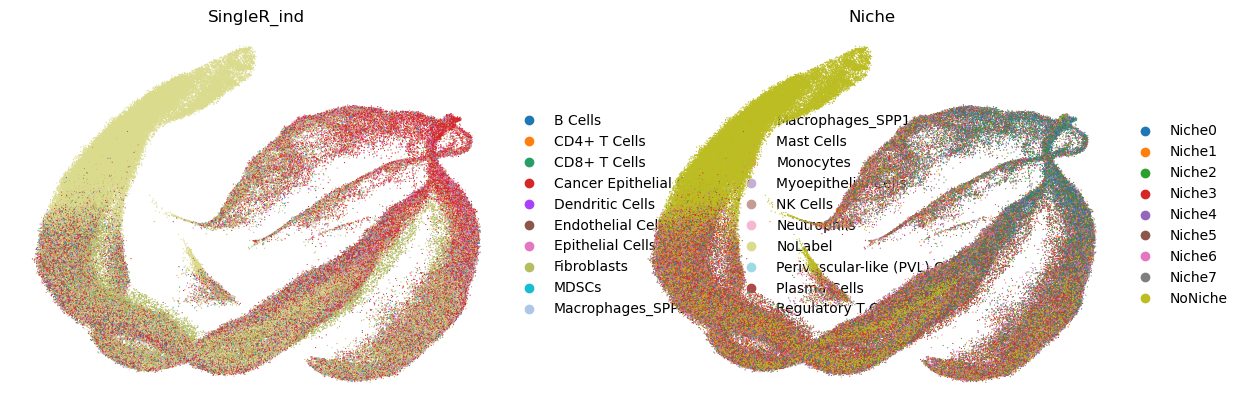

Wrote: /oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/MATMA3_current_saved_with_SingleR_Niche.h5ad


In [26]:
# =========================
# Sanity checks
# =========================
adata_nf = sc.read_h5ad("/oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/MATMA3_current_saved.h5ad")

n_total = adata_nf.n_obs

n_celltype_labeled = int((adata_nf.obs[out_celltype_key] != missing_celltype).sum())
n_niche_labeled = int((adata_nf.obs[out_niche_key] != missing_niche).sum())

print("\nTransfer summary:")
print("Total cells:", n_total)
print(f"Cell type labeled: {n_celltype_labeled}")
print(f"Cell type missing: {n_total - n_celltype_labeled}")
print(f"Niche labeled: {n_niche_labeled}")
print(f"Niche missing: {n_total - n_niche_labeled}")

print("\nTop SingleR_ind counts:")
display(adata_nf.obs[out_celltype_key].value_counts().head(20))

print("\nTop Niche counts:")
display(adata_nf.obs[out_niche_key].value_counts().head(20))

print("\nTop SingleR_ind_Niche counts:")
display(adata_nf.obs["SingleR_ind_Niche"].value_counts().head(20))

# =========================
# Plot quick check if UMAP exists
# =========================
if "X_umap_NF" in adata_nf.obsm:
    adata_nf.obsm["X_nf_umap_plot"] = adata_nf.obsm["X_umap_NF"]

    sc.pl.embedding(
        adata_nf,
        basis="nf_umap_plot",
        color=[out_celltype_key, out_niche_key],
        size=3,
        frameon=False,
        ncols=2
    )

# =========================
# Save
# =========================
out_path = Path(out_h5ad)
out_path.parent.mkdir(parents=True, exist_ok=True)

adata_nf.write_h5ad(out_path)
print("Wrote:", out_path)

# Cancer cell analysis

In [27]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import mygene

# =========================
# Inputs
# =========================
h5ad_path = "/oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/MATMA3_current_saved_with_SingleR_Niche.h5ad"

celltype_col = "SingleR_ind"
target_celltype = "Cancer Epithelial Cells"

cluster_key = "leiden_NF_res0.2"

out_dir = "/oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/DEG_CancerEpithelial_leiden_NF_res0.2"
os.makedirs(out_dir, exist_ok=True)

deg_key = f"rank_genes_{target_celltype.replace(' ', '_')}_{cluster_key}"

# =========================
# Load object
# =========================
adata = ad.read_h5ad(h5ad_path)

print(adata)
print("Cell type column exists:", celltype_col in adata.obs.columns)
print("Cluster key exists:", cluster_key in adata.obs.columns)

print("\nTop cell types:")
print(adata.obs[celltype_col].value_counts().head(20))

print("\nLeiden clusters:")
print(adata.obs[cluster_key].value_counts().sort_index())

AnnData object with n_obs × n_vars = 219363 × 20310
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_0.85', 'falsecode_quanti

In [28]:
# =========================
# Subset to Cancer Epithelial Cells
# =========================
mask = adata.obs[celltype_col].astype(str) == target_celltype

adata_epi = adata[mask].copy()

print("Cancer epithelial cells:", adata_epi.n_obs)
print("\nCluster counts within cancer epithelial cells:")
print(adata_epi.obs[cluster_key].value_counts().sort_index())

# Drop unused categories
adata_epi.obs[cluster_key] = adata_epi.obs[cluster_key].astype("category")
adata_epi.obs[cluster_key] = adata_epi.obs[cluster_key].cat.remove_unused_categories()

Cancer epithelial cells: 42529

Cluster counts within cancer epithelial cells:
0    11342
1     5280
2       36
3     4609
4     3753
5     8481
6     5057
7     1996
8     1855
9      120
Name: leiden_NF_res0.2, dtype: int64


/home/groups/ccurtis2/bgsimon/miniconda/envs/nicheformer_env/lib/python3.9/site-packages/scanpy/plotting/_tools/__init__.py:449: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ymin, ymax)


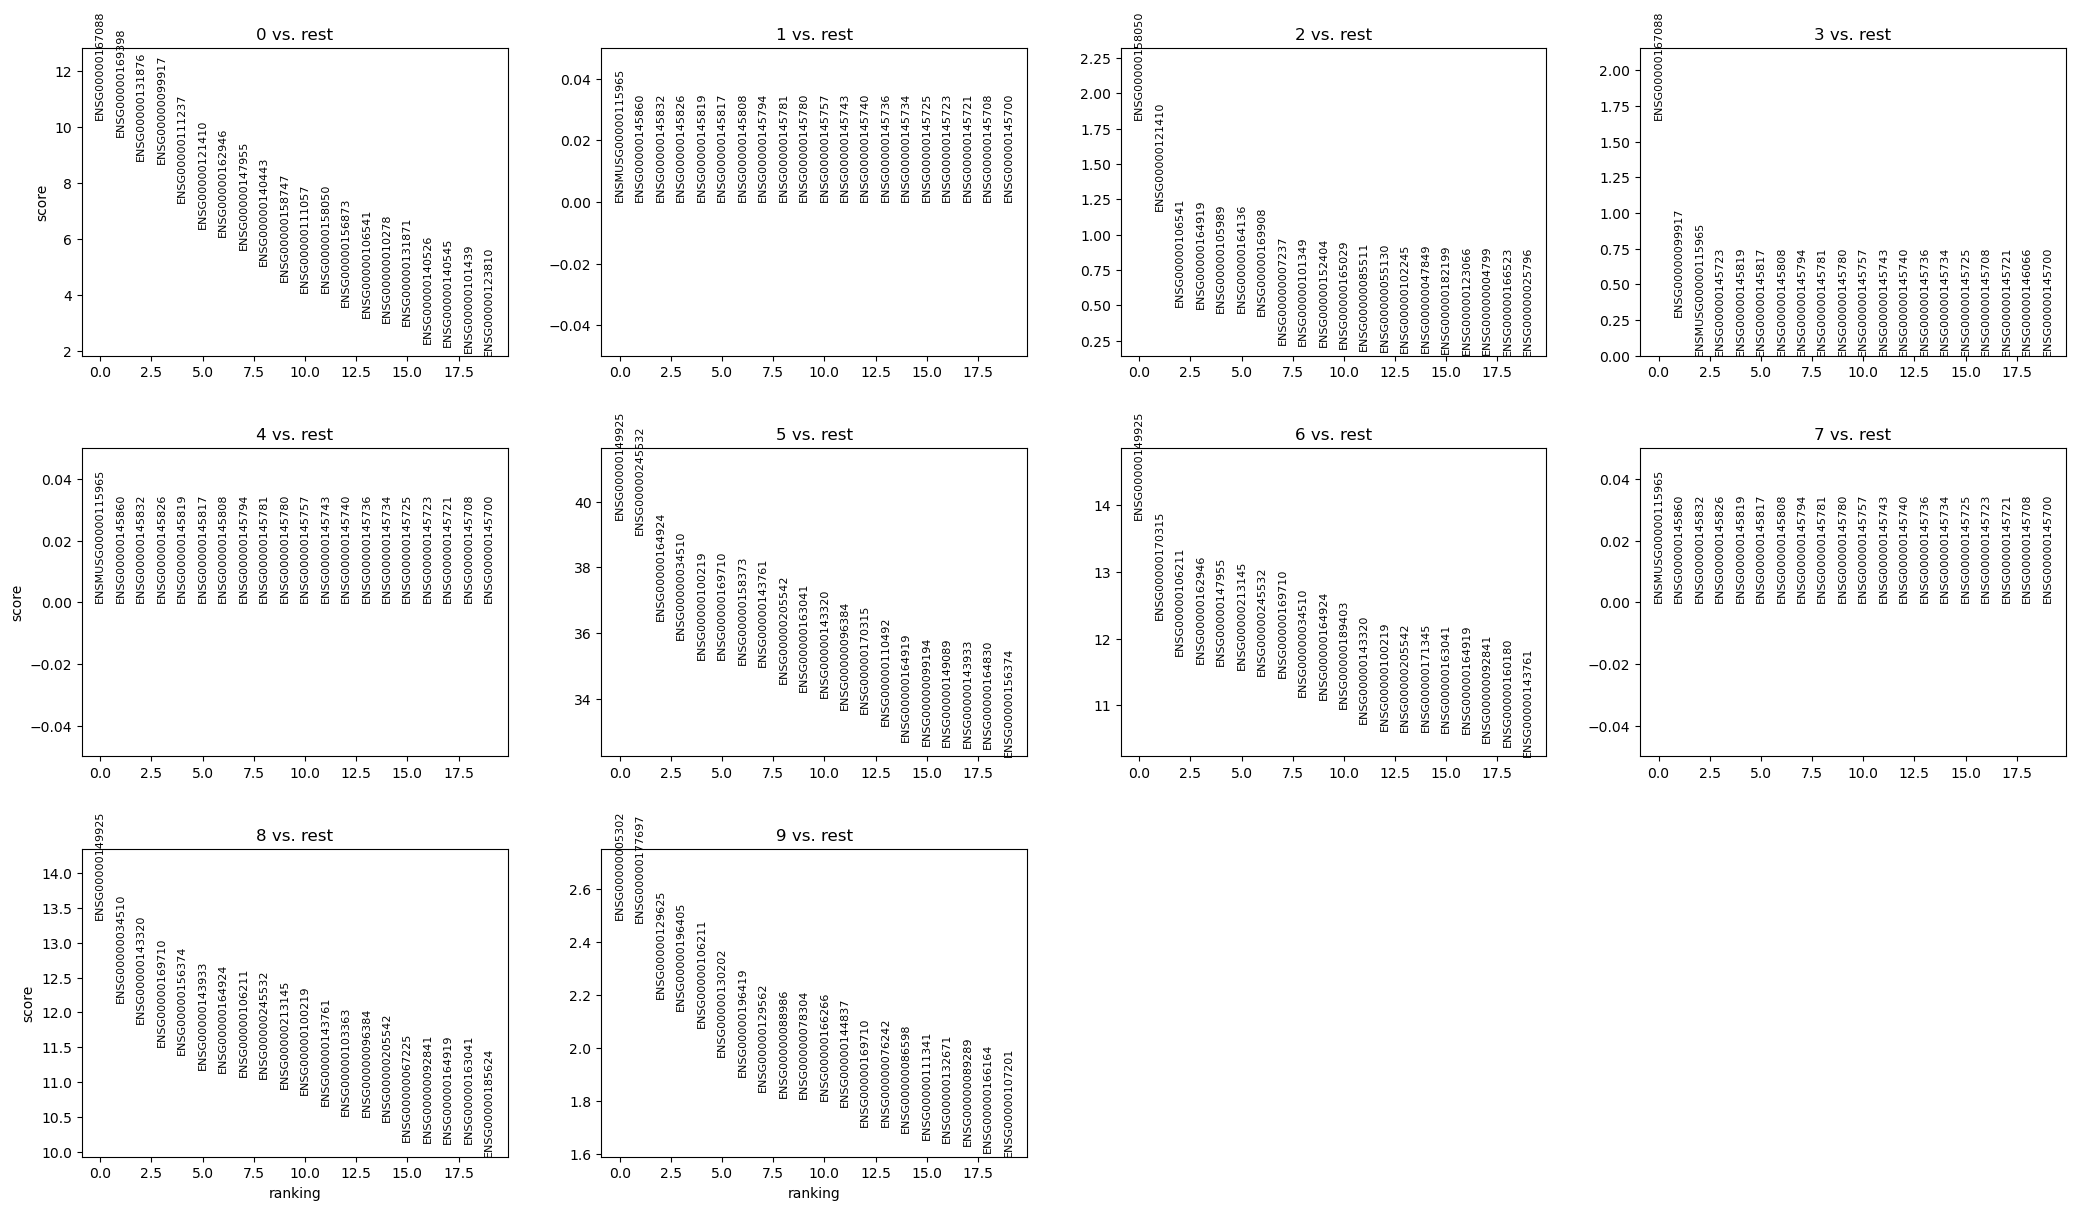

In [30]:
# =========================
# Prepare for DEG
# =========================
adata_de = adata_epi.copy()

adata_de.var["ensembl_id"] = adata_de.var_names.astype(str)

# Normalize/log-transform raw counts
sc.pp.normalize_total(adata_de, target_sum=1e4)
sc.pp.log1p(adata_de)

# =========================
# DEG: each Leiden cluster vs all other cancer epithelial cells
# =========================
sc.tl.rank_genes_groups(
    adata_de,
    groupby=cluster_key,
    method="wilcoxon",
    key_added=deg_key,
    use_raw=False,
    pts=True
)

sc.pl.rank_genes_groups(
    adata_de,
    key=deg_key,
    n_genes=20,
    sharey=False
)

In [31]:
# =========================
# Export DEGs
# =========================
all_tables = []

for cluster in adata_de.obs[cluster_key].cat.categories:
    df = sc.get.rank_genes_groups_df(
        adata_de,
        group=cluster,
        key=deg_key
    )
    
    df["cluster"] = cluster
    df = df.rename(columns={"names": "ensembl_id"})
    all_tables.append(df)

all_degs = pd.concat(all_tables, axis=0)

out_csv = f"{out_dir}/all_DEGs_CancerEpithelial_by_{cluster_key}_ensembl.csv"
all_degs.to_csv(out_csv, index=False)

print("Saved:", out_csv)
all_degs.head()

Saved: /oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/DEG_CancerEpithelial_leiden_NF_res0.2/all_DEGs_CancerEpithelial_by_leiden_NF_res0.2_ensembl.csv


,ensembl_id,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,cluster
0,ENSG00000167088,10.278657,0.305803,8.794492e-25,1.786161e-20,0.993035,0.958701,0
1,ENSG00000169398,9.646106,0.455303,5.105775e-22,5.184914e-18,0.807970,0.723026,0
2,ENSG00000131876,8.811906,0.310037,1.230358e-18,8.329527e-15,0.504585,0.471446,0
3,ENSG00000099917,8.685062,0.515245,3.785332e-18,1.922002e-14,0.904602,0.806297,0
4,ENSG00000111237,7.300475,0.515265,2.867534e-13,1.164792e-09,0.936431,0.841056,0


In [32]:
# =========================
# Add gene symbols
# =========================
unique_ens = all_degs["ensembl_id"].dropna().astype(str).unique().tolist()

mg = mygene.MyGeneInfo()

query = mg.querymany(
    unique_ens,
    scopes="ensembl.gene",
    fields="symbol,name",
    species="human",
    as_dataframe=True,
    df_index=True,
    verbose=False,
)

ens_to_symbol = {}
ens_to_name = {}

for ens in unique_ens:
    if ens not in query.index:
        continue

    row = query.loc[ens]

    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]

    symbol = row.get("symbol", None)
    name = row.get("name", None)

    if pd.notna(symbol):
        ens_to_symbol[ens] = symbol

    if pd.notna(name):
        ens_to_name[ens] = name

all_degs["gene_symbol"] = all_degs["ensembl_id"].map(ens_to_symbol)
all_degs["gene_name"] = all_degs["ensembl_id"].map(ens_to_name)

preferred_cols = [
    "cluster",
    "gene_symbol",
    "gene_name",
    "ensembl_id",
    "scores",
    "logfoldchanges",
    "pvals",
    "pvals_adj",
    "pct_nz_group",
    "pct_nz_reference",
]

existing = [c for c in preferred_cols if c in all_degs.columns]
remaining = [c for c in all_degs.columns if c not in existing]

all_degs = all_degs[existing + remaining]

out_csv = f"{out_dir}/all_DEGs_CancerEpithelial_by_{cluster_key}_with_symbols.csv"
all_degs.to_csv(out_csv, index=False)

print("Saved:", out_csv)
all_degs.head(50)

Saved: /oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/DEG_CancerEpithelial_leiden_NF_res0.2/all_DEGs_CancerEpithelial_by_leiden_NF_res0.2_with_symbols.csv


,cluster,gene_symbol,gene_name,ensembl_id,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,SNRPD1,small nuclear ribonucleoprotein D1 polypeptide,ENSG00000167088,10.278657,0.305803,8.794492e-25,1.786161e-20,0.993035,0.958701
1,0,PTK2,protein tyrosine kinase 2,ENSG00000169398,9.646106,0.455303,5.105775e-22,5.184914e-18,0.807970,0.723026
2,0,SNRPA1,small nuclear ribonucleoprotein polypeptide A',ENSG00000131876,8.811906,0.310037,1.230358e-18,8.329527e-15,0.504585,0.471446
3,0,MED15,mediator complex subunit 15,ENSG00000099917,8.685062,0.515245,3.785332e-18,1.922002e-14,0.904602,0.806297
4,0,VPS29,VPS29 retromer complex component,ENSG00000111237,7.300475,0.515265,2.867534e-13,1.164792e-09,0.936431,0.841056
5,0,A1BG,alpha-1-B glycoprotein,ENSG00000121410,6.362281,0.335732,1.987793e-10,6.728681e-07,0.829660,0.765543
6,0,DISC1,DISC1 scaffold protein,ENSG00000162946,6.071237,0.180200,1.269285e-09,3.222398e-06,0.459619,0.448777
7,0,SIGMAR1,sigma non-opioid intracellular receptor 1,ENSG00000147955,5.612344,0.167857,1.996038e-08,4.504392e-05,0.520190,0.505820
8,0,IGF1R,insulin like growth factor 1 receptor,ENSG00000140443,5.037229,0.342647,4.723199e-07,6.852012e-04,0.241404,0.217783
9,0,NBL1,"NBL1, DAN family BMP antagonist",ENSG00000158747,4.478746,0.389663,7.508263e-06,5.891627e-03,0.171134,0.146728


In [33]:
# =========================
# Positive markers only: top 25 per cluster
# =========================
top_n = 25
padj_cutoff = 0.05
min_logfc = 0.0

positive_top25 = (
    all_degs[
        (all_degs["logfoldchanges"] > min_logfc) &
        (all_degs["pvals_adj"] < padj_cutoff)
    ]
    .sort_values(
        ["cluster", "pvals_adj", "logfoldchanges", "scores"],
        ascending=[True, True, False, False]
    )
    .groupby("cluster", group_keys=False)
    .head(top_n)
)

out_csv = f"{out_dir}/top_{top_n}_positive_markers_CancerEpithelial_by_{cluster_key}_with_symbols.csv"
positive_top25.to_csv(out_csv, index=False)

print("Saved:", out_csv)
print("\nPositive markers per cluster:")
print(positive_top25["cluster"].value_counts().sort_index())

positive_top25.head(50)

Saved: /oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/DEG_CancerEpithelial_leiden_NF_res0.2/top_25_positive_markers_CancerEpithelial_by_leiden_NF_res0.2_with_symbols.csv

Positive markers per cluster:
0    12
5    25
6    25
8    25
Name: cluster, dtype: int64


,cluster,gene_symbol,gene_name,ensembl_id,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,SNRPD1,small nuclear ribonucleoprotein D1 polypeptide,ENSG00000167088,10.278657,0.305803,8.794492e-25,1.786161e-20,0.993035,0.958701
1,0,PTK2,protein tyrosine kinase 2,ENSG00000169398,9.646106,0.455303,5.105775e-22,5.184914e-18,0.807970,0.723026
2,0,SNRPA1,small nuclear ribonucleoprotein polypeptide A',ENSG00000131876,8.811906,0.310037,1.230358e-18,8.329527e-15,0.504585,0.471446
3,0,MED15,mediator complex subunit 15,ENSG00000099917,8.685062,0.515245,3.785332e-18,1.922002e-14,0.904602,0.806297
4,0,VPS29,VPS29 retromer complex component,ENSG00000111237,7.300475,0.515265,2.867534e-13,1.164792e-09,0.936431,0.841056
5,0,A1BG,alpha-1-B glycoprotein,ENSG00000121410,6.362281,0.335732,1.987793e-10,6.728681e-07,0.829660,0.765543
6,0,DISC1,DISC1 scaffold protein,ENSG00000162946,6.071237,0.180200,1.269285e-09,3.222398e-06,0.459619,0.448777
7,0,SIGMAR1,sigma non-opioid intracellular receptor 1,ENSG00000147955,5.612344,0.167857,1.996038e-08,4.504392e-05,0.520190,0.505820
8,0,IGF1R,insulin like growth factor 1 receptor,ENSG00000140443,5.037229,0.342647,4.723199e-07,6.852012e-04,0.241404,0.217783
9,0,NBL1,"NBL1, DAN family BMP antagonist",ENSG00000158747,4.478746,0.389663,7.508263e-06,5.891627e-03,0.171134,0.146728


In [35]:
import scanpy as sc
import anndata as ad

# =========================
# Inputs
# =========================
h5ad_path = "/oak/stanford/groups/ccurtis2/users/bgsimon/MultimodalSpatialIntegration/Nicheformer/nicheformer/my_outputs/4.24.26/MATMA3_current_saved_with_SingleR_Niche.h5ad"

celltype_col = "SingleR_ind"
target_celltype = "Cancer Epithelial Cells"

niche_col = "Niche"

# =========================
# Load object
# =========================
adata = ad.read_h5ad(h5ad_path)

print(adata)

print("\nCell type counts:")
print(adata.obs[celltype_col].value_counts().head(20))

print("\nNiche counts:")
print(adata.obs[niche_col].value_counts().head(20))

AnnData object with n_obs × n_vars = 219363 × 20310
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.Membrane', 'Max.Membrane', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'SplitRatioToLocal', 'NucArea', 'NucAspectRatio', 'Circularity', 'Eccentricity', 'Perimeter', 'Solidity', 'assay_type', 'version', 'Run_Tissue_name', 'Panel', 'cellSegmentationSetId', 'cellSegmentationSetName', 'slide_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_0.85', 'falsecode_quanti

In [36]:
# =========================
# Subset to cancer epithelial cells
# =========================
mask = adata.obs[celltype_col].astype(str) == target_celltype

adata_epi = adata[mask].copy()

print("Cancer epithelial cells:", adata_epi.n_obs)

print("\nNiche distribution within cancer epithelial cells:")
print(adata_epi.obs[niche_col].value_counts())

Cancer epithelial cells: 42529

Niche distribution within cancer epithelial cells:
Niche7     13430
Niche5     10074
Niche2      7609
Niche0      4466
Niche6      3302
Niche3      1766
Niche1      1566
NoNiche      247
Niche4        69
Name: Niche, dtype: int64


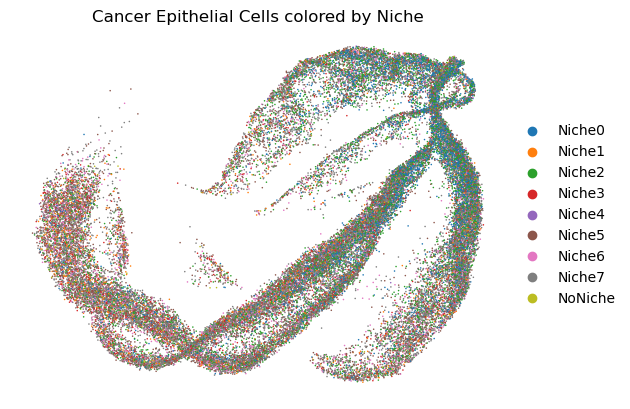

In [37]:
# =========================
# Plot existing Nicheformer UMAP
# =========================
adata_epi.obsm["X_nf_umap_plot"] = adata_epi.obsm["X_umap_NF"]

sc.pl.embedding(
    adata_epi,
    basis="nf_umap_plot",
    color=niche_col,
    size=5,
    frameon=False,
    title="Cancer Epithelial Cells colored by Niche",
    legend_loc="right margin"
)